# Broken-Tether 🔗
### Two stocks that move together drift apart — bet they snap back. Does the tether hold?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Stays tethered?: Breaks](https://img.shields.io/badge/Stays_tethered%3F-Breaks-8b949e?style=flat-square)

Here's the oldest trick in statistical arbitrage: find two assets that move together — two oil majors, two country funds — and watch the **spread** between them. When it stretches unusually wide, bet it'll close: short the one that ran up, buy the one that lagged, and collect when they converge. If the pair is truly *cointegrated*, the spread is a rubber band that always pulls back.

This is the desk's sixth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §3.8). We prove our tools on a synthetic **cointegrated** pair (a real rubber band) and a **spurious** one (two random walks that merely drifted together for a while), then turn them loose on real ETF pairs — and find the tether **breaks**: the relationship that looked rock solid in one half of history snaps in the next.

> 📓 **Plain-language layer.** The spread half-life, the in/out-of-sample split and the false-positive maths are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** tape, so the real-ETF numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from broken_tether import data, spread, strategy, decompose, extension

# Offline synthetic pairs: a COINTEGRATED pair (stationary spread, tradable) and a SPURIOUS one (two
# independent random walks that drift together). The real ETF verdict is in ../docs/results.md.
coint, _    = data.synthetic_pair(revert_rho=0.93, seed=23)   # genuinely cointegrated
spur,  _    = data.synthetic_pair(revert_rho=1.0,  seed=23)   # spurious (null)
print("two synthetic pairs: one cointegrated, one spurious")


two synthetic pairs: one cointegrated, one spurious


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the spread mean-revert? | 🟡 **If the pair is truly cointegrated, yes** — a short, clean half-life. But real ETF pairs are barely, unstably cointegrated. |
| Does it survive out of sample? | 🚫 **Rarely.** Of **45** real ETF pairs, **1** keeps a positive Sharpe in the second half. |
| Is the cointegration even real? | ⚪ **Often selection.** **3%** of *independent random walks* look cointegrated by chance, and the hedge ratio drifts **209%** of its level. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Stays tethered? `BREAKS`** — a real mechanism on a stable pair, but stable pairs are rare and the relationship won't sit still.

## 1 · The claim 📣

Two cointegrated assets share a long-run anchor: the spread `log A − β·log B` is *stationary* — it wanders around a fixed mean and always returns. Trade it: when the spread is stretched (z-score high), bet on reversion. Here's our synthetic **cointegrated** pair's spread, with the z-score bands that trigger the trade:

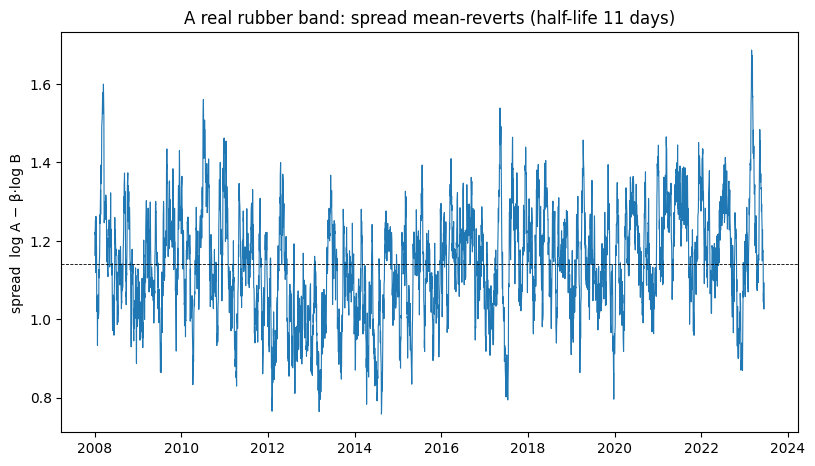

spread half-life 11 days -- short enough to trade the snap-backs.


In [2]:
sp = spread.spread(coint['A'], coint['B']); z = spread.zscore(sp, 63)
hl = spread.half_life(sp)
fig, ax = plt.subplots()
ax.plot(sp.index, sp.values, lw=.8); ax.axhline(sp.mean(), c='k', lw=.6, ls='--')
ax.set_ylabel('spread  log A − β·log B'); ax.set_title(f'A real rubber band: spread mean-reverts (half-life {hl:.0f} days)')
plt.show()
print(f'spread half-life {hl:.0f} days -- short enough to trade the snap-backs.')

## 2 · So what? 💰

A genuine cointegrated pair is the dream of market-neutral trading: a spread that reverts regardless of where the market goes, low correlation to everything, a steady drip of convergence profits. It's the seed of the whole statistical-arbitrage industry. The catch the desk always checks: cointegration is a *statistical* relationship estimated from the past — and the past is a slippery guide to whether two things will keep moving together.

## 3 · How we'd know 🔬

Three checks:

1. **Is the spread really stationary?** Its half-life — short means tradable, near-infinite means a random walk in disguise.
2. **Does it survive out of sample?** Fit and trade in the first half; does the second half still pay?
3. **Is the cointegration real or selection?** How many *independent* random walks look cointegrated by chance, and how much the hedge ratio drifts.

**Breaks line:** the in-sample winners don't repeat, most candidates fail the second half, and the relationship (β) wanders.

## 4 · The teardown 🔧

### 4a · Real cointegration vs a coincidence
The half-life cleanly separates a genuine pair from two walks that merely drifted together.

In [3]:
for label, px in [('cointegrated', coint), ('spurious (two random walks)', spur)]:
    st = spread.stationarity(px['A'], px['B'])
    cmp = strategy.compare(px['A'], px['B'], cost_bps=2.0)
    oos = decompose.in_sample_vs_oos(px['A'], px['B'], cost_bps=2.0)
    print(f"{label:28s}: half-life {st['half_life_days']:.0f}d | Sharpe {cmp['sharpe']:+.2f} | "
          f"in-sample {oos['first_half_sharpe']:+.2f} -> out-of-sample {oos['second_half_sharpe']:+.2f}")

cointegrated                : half-life 11d | Sharpe +0.29 | in-sample +0.50 -> out-of-sample +0.13


spurious (two random walks) : half-life 82d | Sharpe +0.22 | in-sample +0.25 -> out-of-sample +0.11


The cointegrated pair has a short half-life and a positive (if thin) edge; the spurious one has a long half-life and an out-of-sample collapse. Note even the *real* pair's Sharpe is modest — pairs trading is a thin edge even at its best.

### 4b · The selection trap
Scan a universe and you'll *find* cointegrated pairs — even among series with no relationship at all. Here's how many independent random walks look cointegrated by luck:

In [4]:
spur_res = decompose.spurious_pairs(n_series=20, seed=1)
print(f"{spur_res['n_look_cointegrated']}/{spur_res['n_pairs']} independent random-walk pairs "
      f"show a short spread half-life by chance = {spur_res['false_positive_rate']:.0%} false positives")
print(f"median half-life of these no-relationship pairs: {spur_res['median_half_life']:.0f} days")

5/190 independent random-walk pairs show a short spread half-life by chance = 3% false positives
median half-life of these no-relationship pairs: 217 days


### 4c · On the real market — the tether breaks
On real ETF pairs (quoted from [`../docs/results.md`](../docs/results.md)):

- Of **45** candidate pairs, only **1** survives out of sample.
- The best first-half pair, **QQQ/EWJ** (Sharpe **+0.61**), collapses to **+0.18** in the second half — its hedge ratio drifting **87%** of its level.
- The first-half ranking barely predicts the second (rank correlation **+0.17**) — picking pairs on past performance is picking noise.

## 5 · The verdict 🧾

- **Real mechanism, thin edge** — a true cointegrated pair reverts, but even then the Sharpe is modest.
- **Breaks out of sample** — only 1/45 real pairs survive; the tether drifts.
- **Mostly selection** — random walks look cointegrated by chance.

> **Signal `WEAK` · Tradability `MIRAGE` · Stays tethered? `BREAKS`.** A beautiful idea that needs the one thing markets rarely grant: a relationship that stays put.

## 6 · Could you trade it? 💸

- **The pairs that look great were cherry-picked** from a scan that surfaces flukes; live, they revert to nothing.
- **The relationship moves** — a hedge ratio that drifts **209%** means you're rebalancing toward a target that keeps sliding.
- **Even a real pair pays thinly** and competes with every other stat-arb desk for the same convergence — the historical edge (Gatev et al.) has decayed since it was published.

> Tradability **`MIRAGE`** on a scanned universe; the worked complement ([`../docs/extension.md`](../docs/extension.md)) shows the in-sample winners don't repeat.

## 7 · Going further 🚪

- **The drift complement** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): the hedge ratio wanders and the in/out-of-sample rank correlation is ~0.
- **Economically-linked pairs.** Two share classes, an ADR vs its local line, a fund vs its NAV — relationships with a *structural* anchor, not a statistical one. Do those hold where scanned ETF pairs don't?
- **A formal cointegration test** (Engle–Granger / Johansen) with a multiple-testing correction, to size the selection bias honestly.

PRs welcome — find a *structurally* tethered pair that survives, or quantify the decay of the classic distance/cointegration trade.